# Parallel Transport and Holonomy

Parallel transport is the operation that lets you compare tangent vectors at different points of a manifold — a prerequisite for message passing in a GNN or convolution on a curved domain. This notebook shows transport along a path, then **holonomy**: a vector carried around a closed loop returns rotated. That rotation is why ambient Euclidean arithmetic is not valid on curved data. Rotate the 3-D scenes to inspect the transported frames.


## 1. Setup

`Manifold.parallel_transport(x, y, v)` carries a tangent vector $v \in T_xM$ along the geodesic to $y$,
giving a vector in $T_yM$. For the sphere this is the exact Levi-Civita transport; for a general Finsler
metric the analogue is the Berwald connection (`finslerax.geometry.BerwaldConnection`), derived from the spray.


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from finslerax.geometry import Sphere
from finslerax.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_sphere,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
sphere = Sphere(radius=1.0)

## 2. Transporting a vector along a path

We transport a vector along a geodesic, one segment at a time. It keeps a constant angle to the path
tangent — the defining property of parallel transport. The cones mark the transported vector at samples
along the curve.


In [2]:
def geodesic(p, q, n=60):
    v = sphere.log_map(p, q)
    ts = jnp.linspace(0, 1, n)
    return jax.vmap(lambda t: sphere.exp_map(p, t * v))(ts)


def transport_along(path, v0):
    def step(v, idx):
        v_new = sphere.parallel_transport(path[idx], path[idx + 1], v)
        return v_new, v_new
    _, vs = jax.lax.scan(step, v0, jnp.arange(path.shape[0] - 1))
    return jnp.concatenate([v0[None], vs], axis=0)


start = jnp.array([1.0, 0.0, 0.0])
end = jnp.array([0.0, 0.6, 0.8]); end = end / jnp.linalg.norm(end)
path = geodesic(start, end, n=60)
v0 = sphere.to_tangent(start, jnp.array([0.0, 1.0, 0.0])); v0 = v0 / jnp.linalg.norm(v0)
vecs = np.array(transport_along(path, v0))
P = np.array(path)
s = slice(0, len(P), 5)

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_path(P, color=PALETTE["ink"], name="geodesic", width=5, show_start=False))
fig.add_trace(plotly_cones(P[s], vecs[s], name="transported vector", sizeref=0.45,
                           color=PALETTE["primary"]))
plotly_layout(fig, "Parallel transport along a geodesic")
fig.show()

## 3. Holonomy on a closed loop

We transport a vector around a spherical triangle: equator point $A$ → equator point $B$ → north pole
$N$ → back to $A$, each leg a geodesic. On a flat space the vector would return unchanged; on the sphere
it returns rotated by the enclosed area (Gauss–Bonnet). For this octant the area is $\pi/2$, so we expect
a $90^\circ$ rotation. The blue and orange cones at $A$ are the initial and returned vectors.


In [3]:
A = jnp.array([1.0, 0.0, 0.0])
B = jnp.array([0.0, 1.0, 0.0])
N = jnp.array([0.0, 0.0, 1.0])
loop = jnp.concatenate([geodesic(A, B, 40), geodesic(B, N, 40), geodesic(N, A, 40)], axis=0)

v_init = sphere.to_tangent(A, jnp.array([0.0, 1.0, 0.0])); v_init = v_init / jnp.linalg.norm(v_init)
loop_vecs = np.array(transport_along(loop, v_init))
v_final = loop_vecs[-1]
cos_ang = float(np.dot(v_init, v_final) / (np.linalg.norm(v_init) * np.linalg.norm(v_final)))
holonomy_deg = np.degrees(np.arccos(np.clip(cos_ang, -1, 1)))
print(f"initial vector : {np.round(np.array(v_init), 3)}")
print(f"returned vector: {np.round(v_final, 3)}")
print(f"holonomy angle : {holonomy_deg:.2f} deg   (enclosed area = pi/2 -> 90)")

L = np.array(loop)
s = slice(0, len(L), 7)
fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_path(L, color=PALETTE["ink"], name="closed loop", width=5, show_start=False))
fig.add_trace(plotly_cones(L[s], loop_vecs[s], name="transported", sizeref=0.4, color=PALETTE["teal"]))
fig.add_trace(plotly_cones(np.array(A)[None], v_init[None], name="initial", sizeref=0.2,
                           color=PALETTE["primary"]))
fig.add_trace(plotly_cones(np.array(A)[None], v_final[None], name="returned", sizeref=0.2,
                           color=PALETTE["accent"]))
plotly_layout(fig, f"Holonomy: the vector returns rotated by {holonomy_deg:.0f} degrees")
fig.show()

initial vector : [0. 1. 0.]
returned vector: [ 0. -0.  1.]
holonomy angle : 90.00 deg   (enclosed area = pi/2 -> 90)


## 4. Holonomy is proportional to enclosed area

Gauss–Bonnet predicts the holonomy of a geodesic loop on the unit sphere equals the solid angle it
encloses. We confirm it by transporting around latitude circles of growing size: a small loop gives
little holonomy, a large loop gives a large rotation.


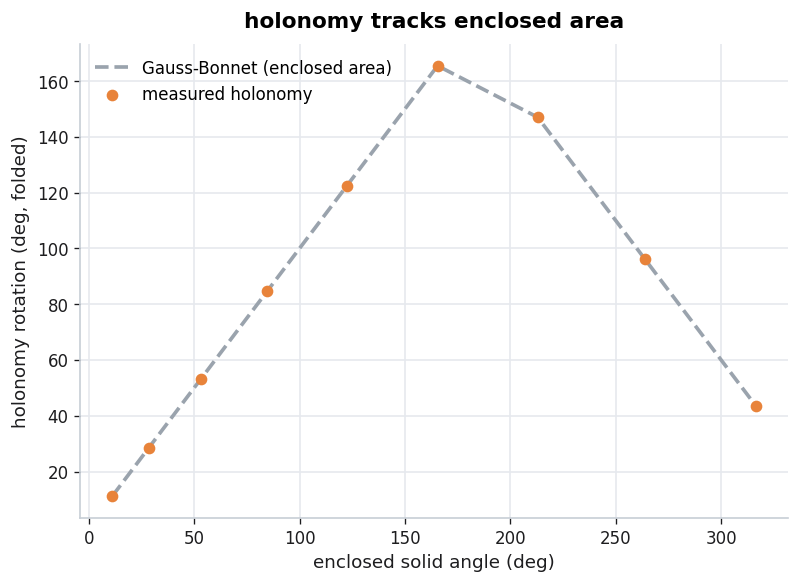

In [4]:
def cap_loop(theta_cap, n=120):
    phi = jnp.linspace(0, 2 * jnp.pi, n)
    r = jnp.sin(theta_cap)
    return jnp.stack([r * jnp.cos(phi), r * jnp.sin(phi),
                      jnp.cos(theta_cap) * jnp.ones_like(phi)], axis=1)


caps = np.linspace(0.25, 1.45, 9)
measured, enclosed = [], []
for tc in caps:
    lp = cap_loop(tc)
    v0c = sphere.to_tangent(lp[0], jnp.array([0.0, 0.0, 1.0])); v0c = v0c / jnp.linalg.norm(v0c)
    vend = np.array(transport_along(lp, v0c))[-1]
    ca = float(np.dot(v0c, vend) / (np.linalg.norm(v0c) * np.linalg.norm(vend)))
    measured.append(np.degrees(np.arccos(np.clip(ca, -1, 1))))
    enclosed.append(np.degrees(2 * np.pi * (1 - np.cos(tc))))

measured = np.minimum(np.array(measured), 360 - np.array(measured))
predicted = np.minimum(np.array(enclosed), 360 - np.array(enclosed))

fig, ax = plt.subplots(figsize=(6.8, 5))
ax.plot(enclosed, predicted, "--", color=PALETTE["muted"], label="Gauss-Bonnet (enclosed area)")
ax.scatter(enclosed, measured, color=PALETTE["accent"], zorder=5, label="measured holonomy")
ax.set_xlabel("enclosed solid angle (deg)"); ax.set_ylabel("holonomy rotation (deg, folded)")
ax.set_title("holonomy tracks enclosed area"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Non-Riemannian holonomy: a deformation, not a rotation

Sections 3 and 4 are Riemannian, and there transport is a **linear isometry**. Going round a loop
rotates the tangent plane rigidly: every vector keeps its length, and the plane turns as one piece.

Finsler geometry keeps less than that. The canonical parallel translation is the **horizontal** one,
carried by the nonlinear connection $N^i_j=\partial G^i/\partial y^j$. It is positively
1-homogeneous rather than linear, and instead of preserving the fundamental tensor it preserves the
norm function $F$. A transported vector must therefore come back onto the indicatrix
$\mathcal I_{x_0}=\{y : F(x_0,y)=1\}$ — but nothing obliges it to come back onto the *Euclidean
circle* it started on, because for a Randers metric the indicatrix is not centred on the origin.

That gives a direct observable. Send a vector once around a closed loop and compare two numbers:

* $F(x_0, Y)$, the Finsler norm — preserved, so both vectors lie on the indicatrix;
* $\lVert Y\rVert$, the ordinary Euclidean length — **not** preserved.

No rotation can do that. The vector has been carried into a different vector of the same Finsler
norm, which is what it means for holonomy to act on $\mathcal I_{x_0}$ by diffeomorphisms rather than
by orthogonal maps.

The control is the Poincaré disk, $F=2\lVert y\rVert/(1-\lVert x\rVert^2)$, which is Riemannian. Its
indicatrix *is* a centred circle, so there the Euclidean length has no choice but to survive.

The Finsler side is `ProjectivelyFlatRanders`, the library's standard model of projectively
flat Randers metrics on the unit ball. With zero drift it is the Funk metric, whose flag
curvature is the constant $-1/4$; `demo_curvature.ipynb` measures that directly.


In [5]:
from finslerax.geometry import EuclideanSpace, ProjectivelyFlatRanders
from finslerax.geometry.metric import FinslerMetric
from finslerax.geometry.transport import BerwaldConnection

disk = EuclideanSpace(dim=2)


class Poincare(FinslerMetric):
    """Poincare disk. Riemannian, constant curvature -1. The control."""

    def metric_fn(self, x, y):
        return 2.0 * jnp.sqrt(jnp.maximum(jnp.dot(y, y), 1e-12)) / (1.0 - jnp.dot(x, x))


CENTRE, RADIUS, STEPS = jnp.array([0.15, 0.05]), 0.62, 6000
START_DIR = jnp.deg2rad(86.0)  # the direction in which the deformation is largest


def disk_loop(steps=STEPS):
    """A closed circle inside the unit disk, parametrised over [0, 1]."""
    ang = 2 * jnp.pi * jnp.linspace(0.0, 1.0, steps + 1)
    xs = CENTRE + RADIUS * jnp.stack([jnp.cos(ang), jnp.sin(ang)], axis=1)
    vs = 2 * jnp.pi * RADIUS * jnp.stack([-jnp.sin(ang), jnp.cos(ang)], axis=1)
    return xs, vs


def unit_cost(metric, x, theta):
    """The vector of Finsler norm 1 in direction theta. F is 1-homogeneous."""
    u = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=-1)
    return u / metric.metric_fn(x, u)


def carry_round(metric, thetas):
    """Transport each unit-cost direction once around the loop."""
    xs, vs = disk_loop()
    conn = BerwaldConnection(metric)
    Y = jax.vmap(unit_cost, in_axes=(None, None, 0))(metric, xs[0], thetas)
    P = jax.vmap(lambda y: conn.parallel_transport(xs, vs, y)[-1])(Y)
    return xs[0], np.asarray(Y), np.asarray(P)


ring = jnp.linspace(0, 2 * jnp.pi, 24, endpoint=False)
funk, poin = ProjectivelyFlatRanders(disk), Poincare(disk)

x0, Y_ring, P_ring = carry_round(funk, ring)
_, Y1, P1 = carry_round(funk, jnp.array([START_DIR]))
_, Yp, Pp = carry_round(poin, jnp.array([START_DIR]))

for name, metric, a, b in (("Funk", funk, Y1[0], P1[0]), ("Poincare", poin, Yp[0], Pp[0])):
    Fa = float(metric.metric_fn(x0, jnp.asarray(a)))
    Fb = float(metric.metric_fn(x0, jnp.asarray(b)))
    la, lb = float(np.linalg.norm(a)), float(np.linalg.norm(b))
    print(
        f"{name:9s}  Finsler norm  {Fa:.5f} -> {Fb:.5f}     "
        f"Euclidean length  {la:.4f} -> {lb:.4f}   (x{lb / la:.3f})"
    )

Funk       Finsler norm  1.00000 -> 0.99802     Euclidean length  0.5409 -> 0.2848   (x0.527)
Poincare   Finsler norm  1.00000 -> 1.00783     Euclidean length  0.2023 -> 0.2039   (x1.008)


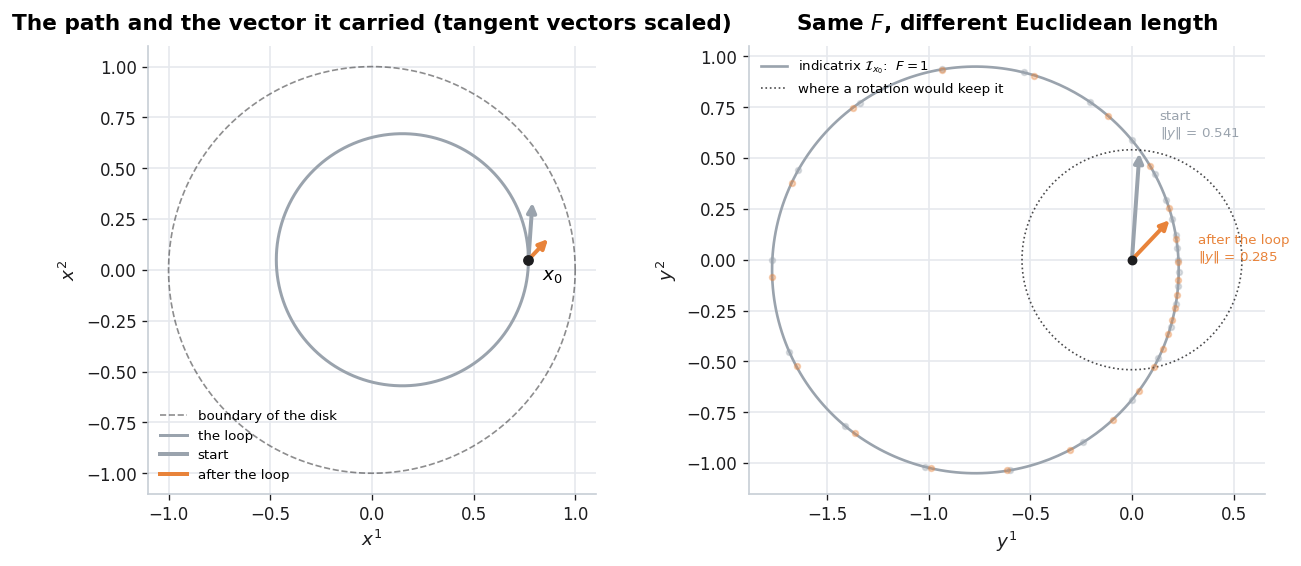

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))
bd = np.linspace(0, 2 * np.pi, 400)

# --- left: the manifold, the loop, and the vector before and after ---
ax1.plot(np.cos(bd), np.sin(bd), color=PALETTE["ink"], lw=1.0, ls="--", alpha=0.5,
         label="boundary of the disk")
ax1.plot(*np.asarray(disk_loop()[0])[::40].T, color=PALETTE["muted"], lw=1.8, label="the loop")
ax1.scatter(*np.asarray(x0), s=30, color=PALETTE["ink"], zorder=6)
ax1.annotate(r"$x_0$", xy=np.asarray(x0), xytext=(8, -12), textcoords="offset points")

S = 0.55  # tangent vectors drawn scaled, so they sit legibly on the base manifold
for vec, col, lab in ((Y1[0], PALETTE["muted"], "start"),
                      (P1[0], PALETTE["accent"], "after the loop")):
    ax1.annotate("", xy=np.asarray(x0) + S * vec, xytext=np.asarray(x0),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4))
    ax1.plot([], [], color=col, lw=2.4, label=lab)
ax1.set_aspect("equal")
ax1.set_title("The path and the vector it carried (tangent vectors scaled)")
ax1.set_xlabel("$x^1$")
ax1.set_ylabel("$x^2$")
ax1.legend(fontsize=8, loc="lower left")

# --- right: the tangent space at x0 ---
curve = np.asarray(jax.vmap(unit_cost, in_axes=(None, None, 0))(
    funk, x0, jnp.linspace(0, 2 * jnp.pi, 400, endpoint=False)))
ax2.plot(*np.vstack([curve, curve[:1]]).T, color=PALETTE["muted"], lw=1.6,
         label=r"indicatrix $\mathcal{I}_{x_0}$:  $F=1$")

r_start = np.linalg.norm(Y1[0])
ax2.plot(r_start * np.cos(bd), r_start * np.sin(bd), color=PALETTE["ink"], lw=1.0, ls=":",
         alpha=0.8, label="where a rotation would keep it")

ax2.scatter(*Y_ring.T, s=12, color=PALETTE["muted"], alpha=0.35, zorder=3)
ax2.scatter(*P_ring.T, s=12, color=PALETTE["accent"], alpha=0.35, zorder=3)

for vec, col, lab in ((Y1[0], PALETTE["muted"], "start"),
                      (P1[0], PALETTE["accent"], "after the loop")):
    ax2.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4))
    off = (12, 8) if lab == "start" else (16, -26)
    ax2.annotate(f"{lab}\n$\\|y\\|$ = {np.linalg.norm(vec):.3f}", xy=vec, xytext=off,
                 textcoords="offset points", fontsize=8, color=col)
ax2.scatter([0], [0], s=24, color=PALETTE["ink"], zorder=6)
ax2.set_aspect("equal")
ax2.set_title("Same $F$, different Euclidean length")
ax2.set_xlabel("$y^1$")
ax2.set_ylabel("$y^2$")
ax2.legend(fontsize=8, loc="upper left")

fig.tight_layout()
plt.show()

Both arrows on the right end on the indicatrix, so both have Finsler norm 1: transport preserved $F$,
as it must. The dotted circle is where a rotation would have been obliged to leave the vector, and
the vector is not on it — the Euclidean length has changed by roughly a factor of two.

The loop did not turn the vector. It **deformed** it into a different vector of the same Finsler
norm. The faint dots show the same thing happening to the whole indicatrix at once: the map carries
$\mathcal{I}_{x_0}$ onto itself, bijectively and smoothly, without being the restriction of any
linear map.

That is the structural difference. In the Riemannian case holonomy lands in $O(n)$, a
finite-dimensional Lie group whose possibilities Berger classified. Here it lands in
$\mathrm{Diff}(\mathcal{I})$, and for almost all Finsler metrics the group it generates is infinite
dimensional (Hubicska–Matveev–Muzsnay).


## 6. Why this matters for ML

* To compare or aggregate tangent features at different manifold points (attention scores, GNN messages,
  flow on a sphere), transport them to a common tangent space first; ambient subtraction is not
  meaningful.
* Holonomy is the obstruction that makes a curved space curved: there is no global frame in which
  transport is trivial. Methods that ignore it accumulate error proportional to the curvature.
* finslerax provides both the Riemannian transport used here (`Manifold.parallel_transport`) and the
  horizontal Finslerian translation (`BerwaldConnection`) for asymmetric or learned metrics, from the
  same scalar $F$. The Riemannian one is a rotation; the Finslerian one need not be, as section 5
  shows.
